In [9]:
# Load data
import pandas as pd

df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")  # ganti sesuai nama file kamu
print(df.shape)
print(df.columns.tolist())
df.head()

(2111, 17)
['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [10]:
# Split and preprocess
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

target_col = "NObeyesdad"

X = df.drop(columns=[target_col]).copy()
y_raw = df[target_col].astype(str)

# Encode target classes -> 0..K-1
y_le = LabelEncoder()
y = y_le.fit_transform(y_raw)
n_classes = len(np.unique(y))
print("Classes:", list(y_le.classes_))

# Identify categorical vs numeric columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("scaler", StandardScaler())]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

print("num_cols:", num_cols)
print("cat_cols:", cat_cols)

Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']
num_cols: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
cat_cols: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


C:\Users\asus\AppData\Local\Temp\ipykernel_25708\3426186035.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001214 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2079
[LightGBM] [Info] Number of data points in the train set: 1688, number of used features: 28
[LightGBM] [Info] Start training from score -2.046805
[LightGBM] [Info] Start training from score -1.997578
[LightGBM] [Info] Start training from score -1.792945
[LightGBM] [Info] Start training from score -1.963240
[LightGBM] [Info] Start training from score -1.874472
[LightGBM] [Info] Start training from score -1.984562
[LightGBM] [Info] Start training from score -1.984562
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

d:\Semester 6\SC\softcomputing\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM: Accuracy 0.9504, Runtime train 14.345s, predict 0.078s


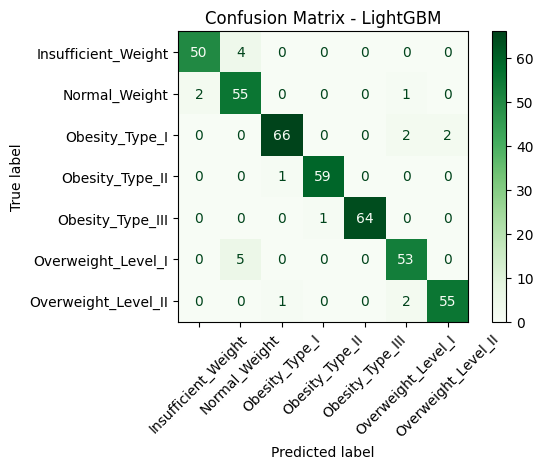

In [15]:
# LightGBM
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    objective="multiclass",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

lgbm_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", lgbm)
])

start = time.time()
lgbm_pipe.fit(X_train, y_train)
rt_train_lgbm = time.time() - start

start = time.time()
pred_lgbm = lgbm_pipe.predict(X_test)
rt_pred_lgbm = time.time() - start

acc_lgbm = accuracy_score(y_test, pred_lgbm)

print(f"LightGBM: Accuracy {acc_lgbm:.4f}, Runtime train {rt_train_lgbm:.3f}s, predict {rt_pred_lgbm:.3f}s")

# =========================
# CONFUSION MATRIX 
# =========================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm_lgbm = confusion_matrix(y_test, pred_lgbm)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm,
    display_labels=y_le.classes_
)

disp.plot(xticks_rotation=45, cmap="Greens")
plt.title("Confusion Matrix - LightGBM")
plt.tight_layout()

plt.show()

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4212 - loss: 1.5760 - val_accuracy: 0.5787 - val_loss: 1.5377 - learning_rate: 0.0010
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6541 - loss: 0.9508 - val_accuracy: 0.6850 - val_loss: 1.2985 - learning_rate: 0.0010
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7392 - loss: 0.7667 - val_accuracy: 0.7244 - val_loss: 1.1326 - learning_rate: 0.0010
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7490 - loss: 0.6885 - val_accuracy: 0.7638 - val_loss: 0.9918 - learning_rate: 0.0010
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8180 - loss: 0.5686 - val_accuracy: 0.7953 - val_loss: 0.8752 - learning_rate: 0.0010
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8264 - loss: 0.5243 - val_accuracy: 0.8071 - val_loss: 0.7609 - learning_rate: 0.0010
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8264 - loss: 0.5051 - 

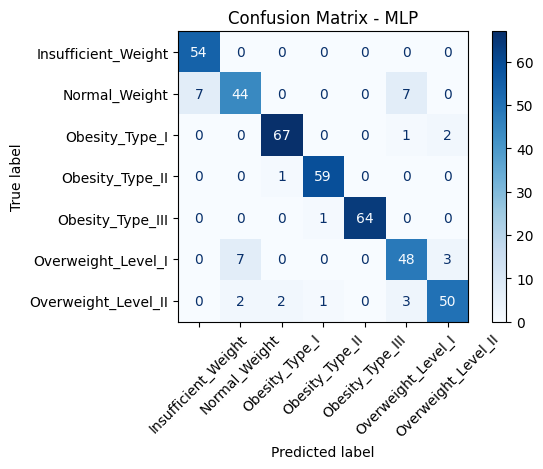

In [16]:
# Neural Network: MPL (TensorFlow)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# transform X using preprocess
X_train_nn = preprocess.fit_transform(X_train)
X_test_nn  = preprocess.transform(X_test)

# OneHotEncoder outputs sparse -> make dense for Keras
X_train_nn = X_train_nn.toarray() if hasattr(X_train_nn, "toarray") else X_train_nn
X_test_nn  = X_test_nn.toarray() if hasattr(X_test_nn, "toarray") else X_test_nn

n_features = X_train_nn.shape[1]

mlp = keras.Sequential([
    layers.Input(shape=(n_features,)),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.2),

    layers.Dense(n_classes, activation="softmax")
])

mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5),
]

start = time.time()
mlp.fit(
    X_train_nn, y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)
rt_train_nn = time.time() - start

start = time.time()
pred_nn = mlp.predict(X_test_nn, verbose=0).argmax(axis=1)
rt_pred_nn = time.time() - start

acc_nn = accuracy_score(y_test, pred_nn)

print(f"TensorFlow MLP: Accuracy {acc_nn:.4f}, Runtime train {rt_train_nn:.3f}s, predict {rt_pred_nn:.3f}s")

# =========================
# CONFUSION MATRIX (MLP)
# =========================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_nn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=y_le.classes_
)

disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix - MLP")
plt.tight_layout()

plt.show()

In [13]:
print("\n=== SUMMARY ===")
print(f"TensorFlow MLP: Accuracy {acc_nn*100:.2f}%, Runtime train {rt_train_nn:.2f}s, predict {rt_pred_nn:.2f}s")
print(f"LightGBM:       Accuracy {acc_lgbm*100:.2f}%, Runtime train {rt_train_lgbm:.2f}s, predict {rt_pred_lgbm:.2f}s")


=== SUMMARY ===
TensorFlow MLP: Accuracy 91.73%, Runtime train 17.66s, predict 0.53s
LightGBM:       Accuracy 95.04%, Runtime train 25.62s, predict 1.92s
